# Employee Turnover Analytics


## Import Libraries:

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from imblearn.over_sampling import SMOTE

## Load Dataset:

In [2]:
df = pd.read_csv("HR_comma_sep.csv")

df.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales,salary
0,0.38,0.53,2,157,3,0,1,0,sales,low
1,0.80,0.86,5,262,6,0,1,0,sales,medium
2,0.11,0.88,7,272,4,0,1,0,sales,medium
3,0.72,0.87,5,223,5,0,1,0,sales,low
4,0.37,0.52,2,159,3,0,1,0,sales,low


## Data Quality Check:

In [3]:
# Check for missing values:
df.isnull().sum()

satisfaction_level       0
last_evaluation          0
number_project           0
average_montly_hours     0
time_spend_company       0
Work_accident            0
left                     0
promotion_last_5years    0
sales                    0
salary                   0
dtype: int64

In [4]:
# Dataset info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14999 entries, 0 to 14998
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   satisfaction_level     14999 non-null  float64
 1   last_evaluation        14999 non-null  float64
 2   number_project         14999 non-null  int64  
 3   average_montly_hours   14999 non-null  int64  
 4   time_spend_company     14999 non-null  int64  
 5   Work_accident          14999 non-null  int64  
 6   left                   14999 non-null  int64  
 7   promotion_last_5years  14999 non-null  int64  
 8   sales                  14999 non-null  object 
 9   salary                 14999 non-null  object 
dtypes: float64(2), int64(6), object(2)
memory usage: 1.1+ MB


## Correlation Heatmap:

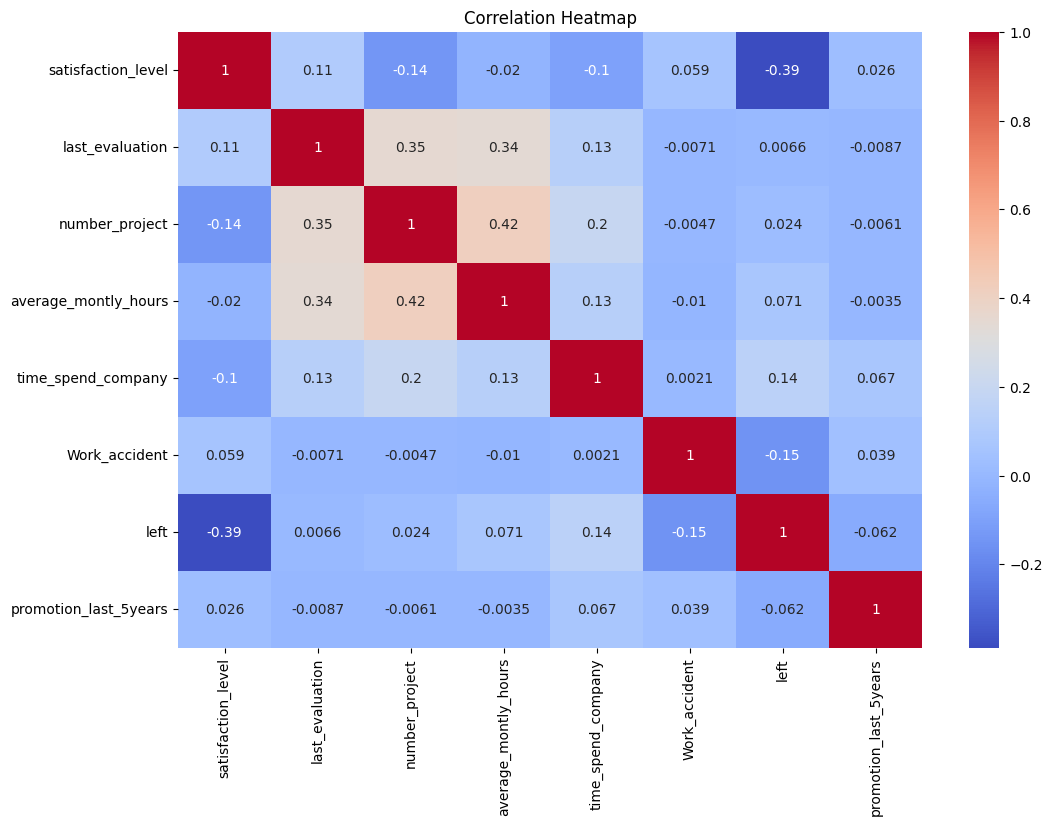

In [6]:
plt.figure(figsize=(12,8))

numeric_df = df.select_dtypes(include=['number'])

sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

## Distribution Plots:

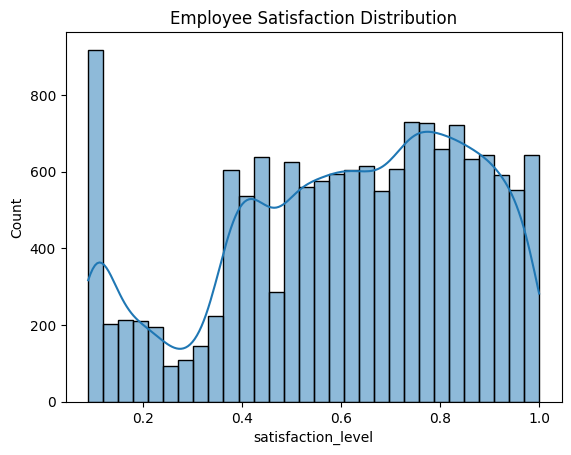

In [7]:
# Satisfaction Level
sns.histplot(df['satisfaction_level'], kde=True)
plt.title("Employee Satisfaction Distribution")
plt.show()

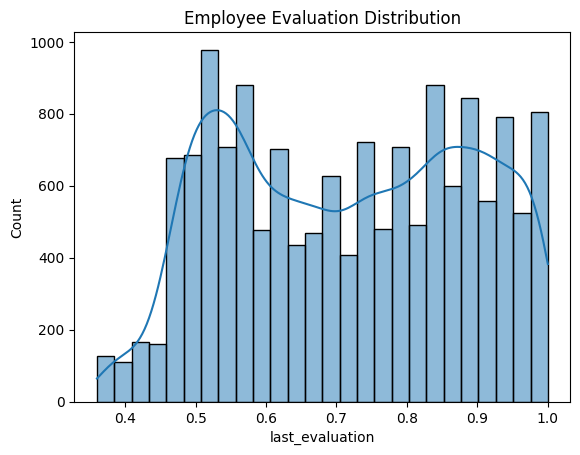

In [8]:
# Last Evaluation
sns.histplot(df['last_evaluation'], kde=True)
plt.title("Employee Evaluation Distribution")
plt.show()

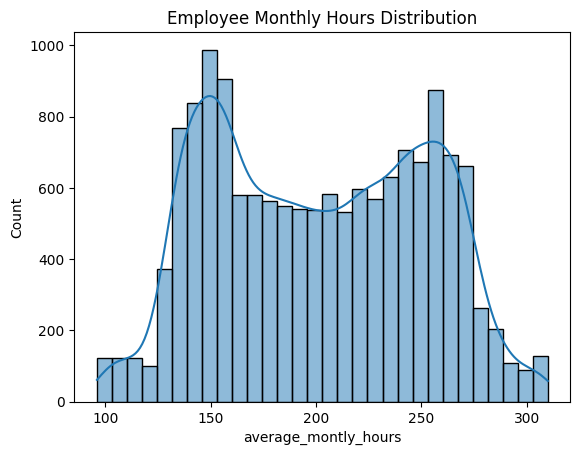

In [9]:
# Average Monthly Hours
sns.histplot(df['average_montly_hours'], kde=True)
plt.title("Employee Monthly Hours Distribution")
plt.show()

## Project Count vs Left:

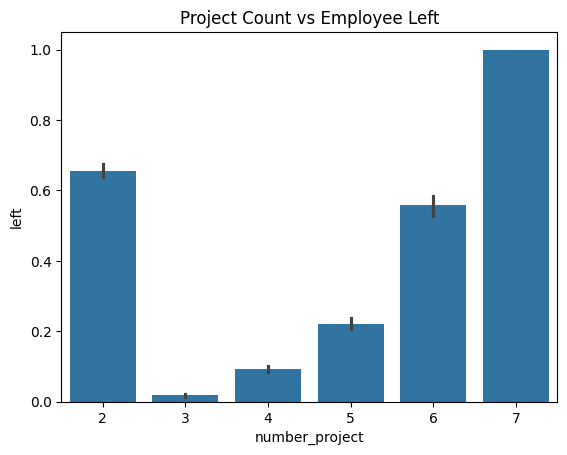

In [10]:
sns.barplot(x='number_project', y='left', data=df)
plt.title("Project Count vs Employee Left")
plt.show()

## Clustering Employees Who Left:

In [11]:
# Select employees who left
left_emp = df[df['left'] == 1]

X = left_emp[['satisfaction_level', 'last_evaluation']]


In [12]:
# KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42)
left_emp['cluster'] = kmeans.fit_predict(X)


C:\Users\admin\AppData\Local\Temp\ipykernel_9816\1258506419.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  left_emp['cluster'] = kmeans.fit_predict(X)


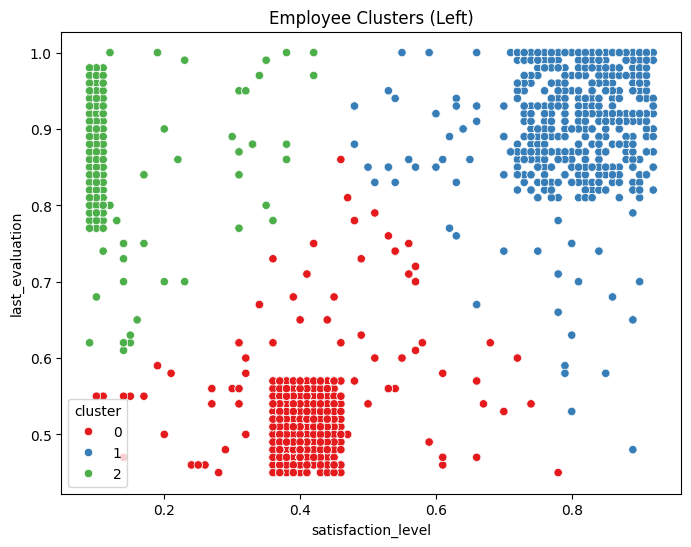

In [13]:
# Plot clusters
plt.figure(figsize=(8,6))
sns.scatterplot(
    x='satisfaction_level',
    y='last_evaluation',
    hue='cluster',
    data=left_emp,
    palette='Set1'
)
plt.title("Employee Clusters (Left)")
plt.show()

## Convert Categorical Variables:

In [14]:
# Separate categorical and numeric
cat = df.select_dtypes(include='object')
num = df.select_dtypes(exclude='object')

In [15]:
# One-hot encoding
cat = pd.get_dummies(cat, drop_first=True)

In [16]:
# Combine
df_new = pd.concat([num, cat], axis=1)

df_new.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,left,promotion_last_5years,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_low,salary_medium
0,0.38,0.53,2,157,3,0,1,0,False,False,False,False,False,False,True,False,False,True,False
1,0.80,0.86,5,262,6,0,1,0,False,False,False,False,False,False,True,False,False,False,True
2,0.11,0.88,7,272,4,0,1,0,False,False,False,False,False,False,True,False,False,False,True
3,0.72,0.87,5,223,5,0,1,0,False,False,False,False,False,False,True,False,False,True,False
4,0.37,0.52,2,159,3,0,1,0,False,False,False,False,False,False,True,False,False,True,False


## Train Test Split:

In [17]:
X = df_new.drop('left', axis=1)
y = df_new['left']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=123
)

## Handle Imbalance Using SMOTE:

In [18]:
smote = SMOTE(random_state=123)

X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

y_train_sm.value_counts()

left
0    9142
1    9142
Name: count, dtype: int64

## Logistic Regression with 5 Fold CV:

In [19]:
lr = LogisticRegression(max_iter=1000)

cv = StratifiedKFold(n_splits=5)

y_pred_lr = cross_val_predict(lr, X_train_sm, y_train_sm, cv=cv)

print("Logistic Regression Report")
print(classification_report(y_train_sm, y_pred_lr))

Logistic Regression Report
              precision    recall  f1-score   support

           0       0.81      0.77      0.79      9142
           1       0.78      0.82      0.80      9142

    accuracy                           0.80     18284
   macro avg       0.80      0.80      0.80     18284
weighted avg       0.80      0.80      0.80     18284



## Random Forest Model:


In [20]:
rf = RandomForestClassifier()

y_pred_rf = cross_val_predict(rf, X_train_sm, y_train_sm, cv=cv)

print("Random Forest Report")
print(classification_report(y_train_sm, y_pred_rf))

Random Forest Report
              precision    recall  f1-score   support

           0       0.97      1.00      0.98      9142
           1       1.00      0.97      0.98      9142

    accuracy                           0.98     18284
   macro avg       0.98      0.98      0.98     18284
weighted avg       0.98      0.98      0.98     18284



## Gradient Boosting Model:

In [21]:
gb = GradientBoostingClassifier()

y_pred_gb = cross_val_predict(gb, X_train_sm, y_train_sm, cv=cv)

print("Gradient Boosting Report")
print(classification_report(y_train_sm, y_pred_gb))

Gradient Boosting Report
              precision    recall  f1-score   support

           0       0.95      0.98      0.96      9142
           1       0.98      0.95      0.96      9142

    accuracy                           0.96     18284
   macro avg       0.96      0.96      0.96     18284
weighted avg       0.96      0.96      0.96     18284



## ROC Curve:


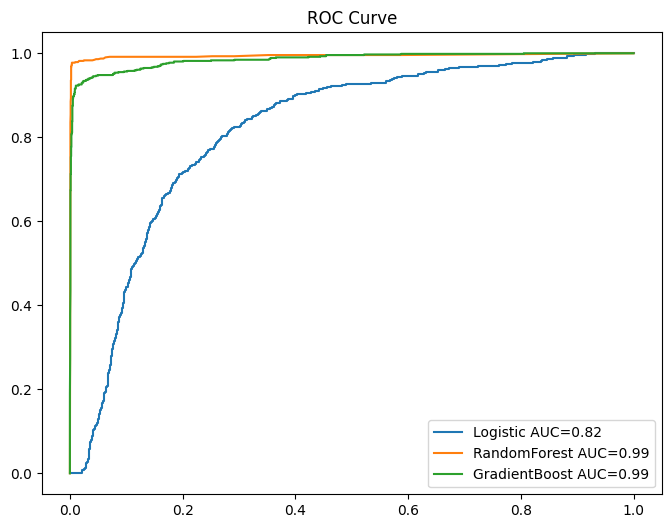

In [22]:
models = {
    "Logistic": lr,
    "RandomForest": rf,
    "GradientBoost": gb
}

plt.figure(figsize=(8,6))

for name, model in models.items():
    model.fit(X_train_sm, y_train_sm)
    prob = model.predict_proba(X_test)[:,1]
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, label=f"{name} AUC={auc:.2f}")

plt.legend()
plt.title("ROC Curve")
plt.show()

## Confusion Matrix:

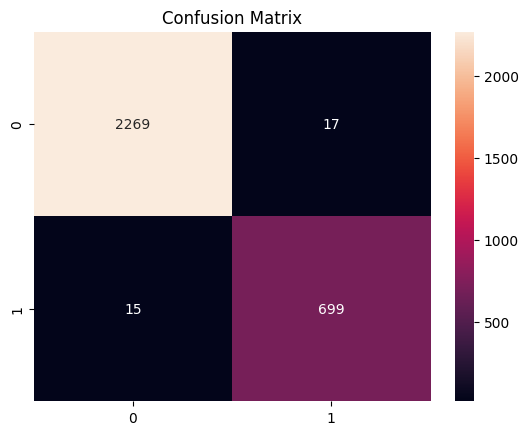

In [23]:
best_model = rf
best_model.fit(X_train_sm, y_train_sm)

y_pred = best_model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.show()

## Predict Turnover Probability:

In [24]:
prob = best_model.predict_proba(X_test)[:,1]

result = X_test.copy()
result['Probability'] = prob

## Risk Zone Classification:

In [25]:
def risk_zone(p):
    if p < 0.20:
        return "Safe Zone"
    elif p < 0.60:
        return "Low Risk"
    elif p < 0.90:
        return "Medium Risk"
    else:
        return "High Risk"

result['Risk Zone'] = result['Probability'].apply(risk_zone)

result.head()

,satisfaction_level,last_evaluation,number_project,average_montly_hours,time_spend_company,Work_accident,promotion_last_5years,sales_RandD,sales_accounting,sales_hr,sales_management,sales_marketing,sales_product_mng,sales_sales,sales_support,sales_technical,salary_low,salary_medium,Probability,Risk Zone
10627,0.98,0.77,3,191,2,0,0,False,False,False,False,False,False,True,False,False,False,True,0.00,Safe Zone
2703,0.76,0.93,3,271,5,0,0,False,False,True,False,False,False,False,False,False,True,False,0.55,Low Risk
6059,0.70,0.93,3,185,4,0,0,False,True,False,False,False,False,False,False,False,False,True,0.03,Safe Zone
3258,0.48,0.61,3,223,3,1,0,False,False,False,False,False,False,False,True,False,False,True,0.02,Safe Zone
4565,0.57,0.90,3,144,2,0,0,False,False,False,False,False,False,False,False,False,False,True,0.00,Safe Zone


## Retention Strategy:


In [27]:
#Print Count
result['Risk Zone'].value_counts()

Risk Zone
Safe Zone      2175
High Risk       654
Low Risk        121
Medium Risk      50
Name: count, dtype: int64